# Neural signal forecasting v9
## time-aware gated axial attention + temporal conv + GCN

## What's New in v9 (Spike-Aware Modeling)
- **Conservative spike awareness:** affi shows occasional upward jumps mid-horizon; v9 adds a light change head to catch these without destabilizing the base value forecast.
- **Fix for mid-horizon jump misses:** v9 explicitly models delta y and up-weights large changes so sudden rises are less likely to be smoothed away.
- **Variance control:** the change loss is weighted with a small lambda, keeping the value head behavior close to v7 while improving jump recall.


In [1]:
# Build dataloader
import torch
import numpy as np
import os
from model_v13 import NFSTNDTModelV13
from utils import *
from trainer import Trainer

input_dir = './'

## What changed in v4
- fix input issue: remove adj from input of forward()

## What's New in v5 Compared to v4
- **New inputs:** optional timestamp tensor `t` with shape `(B, T)` alongside signal `x` (still `(B, T, C, F)`).
- **New modeling assumption:** irregular sampling is allowed; the model uses `delta_t` computed internally from `t`.
- **Architectural change:** time features are encoded (Time2Vec + `delta_t`) and concatenated to signal features *before* the axial attention backbone.
- **Why this helps:** time-awareness reduces the fixed-interval assumption and improves robustness when sampling is uneven or when time context matters.

### Time inputs in this notebook
If your dataset does not include timestamps, we generate a synthetic monotonic `t` using `torch.arange(T)` so the pipeline remains backward compatible. When `delta_t` is constant, v5 behaves like v4 with a richer positional bias.


## Time-aware inputs (v5)
- We construct a timestamp tensor `t` with shape `(B, T)` using `torch.arange(T)` when real timestamps are unavailable.
- The v5 model computes `delta_t = t[:, i] - t[:, i-1]` internally.
- Time2Vec is used inside `model_v5.py` to encode time before the backbone.


In [2]:
# parameters:
# dataset_name = 'beignet'
dataset_name = 'affi'
if dataset_name == 'beignet':
  num_channels = 89
else:
  num_channels = 239

batch_size = 16
num_epochs = 100
learning_rate = 1e-4
hidden_size = 256
n_heads=4
n_layers=3
dropout=0.1
input_size = num_channels

seeds = [0, 1, 2]

# --- Time-based split (train on past, test on future) ---
# Data is assumed to be ordered in time; we avoid random shuffling here.
raw = np.load(f'dataset/train_data_{dataset_name}.npz')['arr_0']
num_total = len(raw)
train_end = int(num_total * 0.8)
val_end = int(num_total * 0.9)

train_data = raw[:train_end]
val_data = raw[train_end:val_end]
test_data = raw[val_end:]



In [3]:
from torch.utils.data import DataLoader
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# Dataset / Dataloader
# ============================================================
train_ds = NeuroForcastDataset(train_data, use_graph=False)
np.savez(
    f'train_data_average_std_{dataset_name}.npz',
    average=train_ds.average,
    std=train_ds.std
)

test_ds = NeuroForcastDataset(
    test_data,
    use_graph=False,
    average=train_ds.average,
    std=train_ds.std
)
val_ds = NeuroForcastDataset(
    val_data,
    use_graph=False,
    average=train_ds.average,
    std=train_ds.std
)

train_data_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_data_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
val_data_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

adj_matrix = compute_adj_matrix(train_data, threshold=0.1).to(torch.device('cuda'))

# ============================================================
# Time handling (unchanged)
# ============================================================
def build_time_tensor(x):
    # x: (B, T, C, F) -> t: (B, T)
    t = torch.arange(x.shape[1], device=x.device, dtype=x.dtype)
    return t.unsqueeze(0).repeat(x.shape[0], 1)

class TimeAwareWrapper(nn.Module):
    """
    Wraps the v13 model so the existing Trainer can call model(x).
    v13 operates on per-channel sequences: (B*C, T, F).
    """
    def __init__(self, base_model, quantiles):
        super().__init__()
        self.base_model = base_model
        self.quantiles = quantiles

    def forward(self, x, t=None):
        # x: (B, T, C, F)
        if t is None:
            t = build_time_tensor(x)

        B, T, C, F = x.shape

        x_flat = x.permute(0, 2, 1, 3).contiguous().view(B * C, T, F)
        t_flat = t.unsqueeze(1).repeat(1, C, 1).view(B * C, T)

        out = self.base_model(x_flat, t_flat)
        y_pred = out["y_pred"]   # (B*C, T, Q)
        dy_pred = out["dy_pred"] # (B*C, T)

        Q = y_pred.shape[-1]
        y_pred = y_pred.view(B, C, T, Q).permute(0, 2, 1, 3).contiguous()
        dy_pred = dy_pred.view(B, C, T).permute(0, 2, 1).contiguous()

        dy_pred = dy_pred.unsqueeze(-1)
        return torch.cat([y_pred, dy_pred], dim=-1)  # (B, T, C, Q+1)

# ============================================================
# Model
# ============================================================
quantiles = [0.1, 0.5, 0.9]

# ============================================================
# v13 Options
# ============================================================
use_spike_weighting = True
spike_weight_factor = 3.0
spike_quantile = 0.95
beta_huber = 0.5
w_y = 1.0
w_change = 0.5
w_cross = 0.05
use_revin = True
revin_affine = True

# ============================================================
# Precompute de-normalization params for feature[0]
# ============================================================
num_channels = train_data.shape[2]
avg_cf = train_ds.average
std_cf = train_ds.std
num_feats = avg_cf.shape[1] // num_channels
avg_f0 = avg_cf.reshape(1, num_channels, num_feats)[..., 0]
std_f0 = std_cf.reshape(1, num_channels, num_feats)[..., 0]
combine_max_f0 = torch.tensor(avg_f0 + 4 * std_f0, dtype=torch.float32)
combine_min_f0 = torch.tensor(avg_f0 - 4 * std_f0, dtype=torch.float32)
scale_f0 = (combine_max_f0 - combine_min_f0) / 2.0

# ============================================================
# v13 Loss (robust + symmetric spike weighting)
# ============================================================
def pinball_loss(y_hat, y, q):
    e = y - y_hat
    return torch.maximum(q * e, (q - 1.0) * e)

def quantile_order_penalty(q10, q50, q90, eps=1e-6):
    diff1 = q10 - q50 + eps
    diff2 = q50 - q90 + eps
    loss = F.relu(diff1).mean() + F.relu(diff2).mean()
    return torch.nan_to_num(loss)

change_loss_fn = torch.nn.SmoothL1Loss(beta=beta_huber, reduction="none")

def spike_weighted_loss_v13(pred_tensor, target, init_steps=10, apply_spike_weight=True, debug_state=None):
    """
    pred_tensor: (B, H, C, Q+1)
    target:      (B, H, C)
    """
    Q = len(quantiles)
    y_pred = pred_tensor[..., :Q]   # (B,H,C,Q)
    dy_pred = pred_tensor[..., Q]   # (B,H,C)
    y_true = target                 # (B,H,C)

    cmax = combine_max_f0.to(y_true.device)
    cmin = combine_min_f0.to(y_true.device)
    scale = scale_f0.to(y_true.device)

    # raw scale for change/spike detection
    y_true_raw = ((y_true + 1.0) / 2.0) * (cmax - cmin) + cmin
    dy_true_raw = y_true_raw[:, 1:, :] - y_true_raw[:, :-1, :]
    dy_true_raw = torch.cat([dy_true_raw[:, :1, :], dy_true_raw], dim=1)

    if apply_spike_weight:
        dy_abs = dy_true_raw.abs()
        max_abs = dy_abs.max()
        if max_abs == 0:
            tau = torch.tensor(1e-6, device=y_true.device, dtype=y_true.dtype)
        else:
            tau = torch.quantile(dy_abs.flatten(), q=spike_quantile)
        spike_mask = (dy_abs > tau).float()
        if debug_state is not None and debug_state.get("batches", 0) < 3:
            spike_ratio = spike_mask.mean().item()
            print(f"Spike ratio: {spike_ratio:.4f} | tau: {tau.item():.6f}")
            debug_state["batches"] = debug_state.get("batches", 0) + 1
        w = 1.0 + spike_weight_factor * spike_mask
    else:
        w = 1.0

    # -------- quantile losses (q10/q50/q90 ALL trained) --------
    q_losses = []
    for k, q in enumerate(quantiles):
        q_loss = pinball_loss(y_pred[..., k], y_true, q)
        q_losses.append((q_loss * w).mean())
    quant_loss = sum(q_losses) / len(q_losses)

    # -------- ordering penalty (kill quantile crossing) --------
    q10, q50, q90 = y_pred[..., 0], y_pred[..., 1], y_pred[..., 2]
    ord_loss = quantile_order_penalty(q10, q50, q90)

    # -------- delta prediction loss (robust) -------------------
    dy_pred_raw = dy_pred * scale
    change_loss = (change_loss_fn(dy_pred_raw, dy_true_raw) * w).mean()

    # -------- total loss --------------------------------------
    total_loss = (
        w_y * quant_loss +
        w_change * change_loss +
        w_cross * ord_loss
    )

    return total_loss

# ============================================================
# Optim / Scheduler
# ============================================================
for seed in seeds:
    set_seed(seed)

    base_model = NFSTNDTModelV13(
        input_size=9,
        hidden_size=hidden_size,
        n_heads=n_heads,
        n_layers=n_layers,
        dropout=dropout,
        num_features=9,
        use_time2vec=True,
        time2vec_k=8,
        use_delta_t=True,
        quantiles=quantiles,
        use_revin=use_revin,
        revin_affine=revin_affine
    ).to(torch.device('cuda'))

    model = TimeAwareWrapper(base_model, quantiles).to(torch.device('cuda'))

    debug_state = {"batches": 0}

    def loss_fn(y_hat, y_true):
        return spike_weighted_loss_v13(
            y_hat,
            y_true,
            init_steps=10,
            apply_spike_weight=use_spike_weighting,
            debug_state=debug_state
        )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-2
    )

    lambda1 = lambda epoch: 0.95 ** (epoch // 20)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda1
    )

    # ============================================================
    # Trainer
    # ============================================================
    save_path = f'./model_{dataset_name}_v13_seed{seed}.pth'

    trainer = Trainer(
        model=model,
        train_data_loader=train_data_loader,
        test_data_loader=test_data_loader,
        val_data_loader=val_data_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=torch.device('cuda'),
        scheduler=scheduler,
        forecasting_mode='multi_step',
        init_steps=10,
        save_path=save_path,
        ckpt_path=None,
        max_grad_norm=1.0,
        validate_every=1,
        save_best=True
    )
    # trainer.train(num_epochs)
    # print("Best val:", trainer.best_val)
    # print("Best weight path:", save_path)

## What's New in v6 Compared to v5
- **Why point forecasting is insufficient:** v5 produces a single trajectory, but real neural signals are noisy and multi-modal; a single point hides ambiguity and can be overconfident when the test distribution shifts.
- **What uncertainty means here:** for each future time and channel, multiple plausible outcomes exist due to measurement noise and changing dynamics.
- **How v6 models predictive uncertainty:** v6 predicts multiple **quantiles** of the target distribution (e.g., 0.1, 0.5, 0.9) using a pinball loss. This yields a median forecast plus uncertainty bands.
- **Why this improves robustness under distribution shift:** quantile outputs avoid overconfident point estimates and provide calibrated ranges that remain useful even when patterns differ from training.

## Output shape (v6)
- Model output: `y_hat` has shape `(B, T, C, Q)` where `Q = len(quantiles)`.
- For multi-step forecasting, the trainer compares `y_hat[:, init_steps:, :, :]` against target `(B, H, C)`.

## What's New in v7 Compared to v6
- **Why autoregressive forecasting is problematic:** rolling predictions forward compounds errors and can drift quickly when the data distribution shifts.
- **How direct multi-horizon prediction improves stability:** v7 predicts the entire future window in a single forward pass, avoiding step-by-step error accumulation.
- **Why time-based evaluation is necessary:** random splits leak future patterns into training; strict temporal splits better match real deployment.
- **How v7 better measures generalization:** per-horizon metrics and interval coverage expose where the model degrades as the horizon grows.

## Direct multi-horizon forecasting (v7)
- Forecast horizon `H = T - init_steps` is predicted directly in one pass (no autoregressive rollout).
- Model output for evaluation: `y_hat_future` has shape `(B, H, C, Q)`.
- **Backward compatibility:** when `H = 1` and horizon weights are uniform, v7 reduces to the v6 objective.

## Temporal evaluation protocol (v7)
- **Train:** earliest 80% of samples
- **Val:** next 10%
- **Test:** final 10% (most recent)
- This mirrors real-world deployment where only past data is available for training.

## Spike-aware loss (v9)
- Compute delta y on the target feature and mark spikes where |delta y| > tau.
- tau is estimated from training data (high-percentile of |delta y|), so thresholds are data-driven.
- Spike horizons receive an extra loss weight to prioritize rare jumps.


Found 3 checkpoint(s): ['.\\model_affi_v13_seed0.pth', '.\\model_affi_v13_seed1.pth', '.\\model_affi_v13_seed2.pth']
Loaded keys: ['time2vec.w0', 'time2vec.b0', 'time2vec.w', 'time2vec.b', 'revin.gamma', 'revin.beta', 'in_proj.weight', 'in_proj.bias', 'encoder.layers.0.self_attn.in_proj_weight', 'encoder.layers.0.self_attn.in_proj_bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.bias', 'encoder.layers.0.linear1.weight', 'encoder.layers.0.linear1.bias', 'encoder.layers.0.linear2.weight', 'encoder.layers.0.linear2.bias', 'encoder.layers.0.norm1.weight', 'encoder.layers.0.norm1.bias', 'encoder.layers.0.norm2.weight', 'encoder.layers.0.norm2.bias']
Loaded keys: ['time2vec.w0', 'time2vec.b0', 'time2vec.w', 'time2vec.b', 'revin.gamma', 'revin.beta', 'in_proj.weight', 'in_proj.bias', 'encoder.layers.0.self_attn.in_proj_weight', 'encoder.layers.0.self_attn.in_proj_bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.

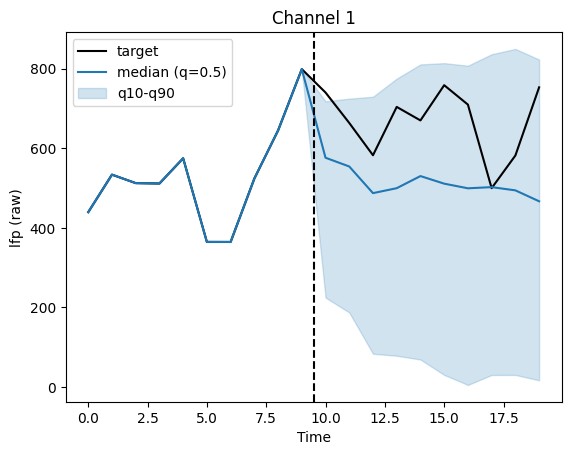

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import glob

INIT_STEPS = 10
DEVICE = torch.device("cuda")

# --- Load ALL v13 seed checkpoints (ensemble) ---
ckpt_paths = sorted(glob.glob(f'./model_{dataset_name}_v13_seed*.pth'))
if not ckpt_paths:
    ckpt_paths = [f'./model_{dataset_name}_v13.pth']
print(f"Found {len(ckpt_paths)} checkpoint(s):", ckpt_paths)

quantiles = [0.1, 0.5, 0.9]
models = []
for ckpt in ckpt_paths:
    base_model_test = NFSTNDTModelV13(
        input_size=9,
        hidden_size=hidden_size,
        n_heads=n_heads,
        n_layers=n_layers,
        dropout=dropout,
        num_features=9,
        use_time2vec=True,
        time2vec_k=8,
        use_delta_t=True,
        quantiles=quantiles,
        use_revin=use_revin,
        revin_affine=revin_affine
    ).to(DEVICE)
    model_test = TimeAwareWrapper(base_model_test, quantiles).to(DEVICE)

    state = torch.load(ckpt, map_location="cpu")
    print("Loaded keys:", list(state.keys())[:20])
    assert not any(k.startswith("base_model.") for k in state.keys())
    assert not any(k.startswith("head.") for k in state.keys())

    base_model_test.load_state_dict(state, strict=True)
    model_test.eval()
    models.append(model_test)

# --- De-normalization helpers (feature 0 only) ---
stats = np.load(f'train_data_average_std_{dataset_name}.npz')
avg_cf = stats['average']  # (1, C*F)
std_cf = stats['std']
num_feats = avg_cf.shape[1] // num_channels
avg_f0 = avg_cf.reshape(1, num_channels, num_feats)[..., 0]
std_f0 = std_cf.reshape(1, num_channels, num_feats)[..., 0]
combine_max = avg_f0 + 4 * std_f0
combine_min = avg_f0 - 4 * std_f0

def denorm_feature0(x, channel_idx=None):
    x_np = x.detach().cpu().numpy() if torch.is_tensor(x) else x
    if x_np.shape[-1] == num_channels:
        return ((x_np + 1) / 2) * (combine_max - combine_min) + combine_min
    if channel_idx is None:
        raise ValueError("channel_idx required for single-channel inputs")
    cmax = combine_max[..., channel_idx]
    cmin = combine_min[..., channel_idx]
    return ((x_np + 1) / 2) * (cmax - cmin) + cmin

def prepare_input_masked(data, init_steps=INIT_STEPS):
    # data: (B,20,C,F)
    future = data.shape[1] - init_steps
    x_in = torch.cat([
        data[:, :init_steps, :, :],
        data[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)
    y_future = data[:, init_steps:, :, 0]  # (B,10,C) feature0 target
    return x_in, y_future

@torch.no_grad()
def eval_metrics_per_horizon(models, loader, device=DEVICE, init_steps=INIT_STEPS, spike_tau=0.0):
    preds_q, preds_dy, tgts = [], [], []
    for batch in loader:
        batch = batch.to(device)  # (B,20,C,F)
        x_in, y_future = prepare_input_masked(batch, init_steps=init_steps)
        t_in = build_time_tensor(x_in)

        outs = []
        for m in models:
            outs.append(m(x_in, t_in))  # (B,20,C,Q+1)
        out = torch.stack(outs, dim=0).mean(dim=0)

        Q = len(quantiles)
        y_hat_full = out[..., :Q]
        dy_hat_full = out[..., Q]

        y_hat_future = y_hat_full[:, init_steps:, :, :]  # (B,H,C,Q)
        dy_hat_future = dy_hat_full[:, init_steps:, :]   # (B,H,C)

        preds_q.append(y_hat_future.detach().cpu())
        preds_dy.append(dy_hat_future.detach().cpu())
        tgts.append(y_future.detach().cpu())

    preds_q = torch.cat(preds_q, dim=0)
    preds_dy = torch.cat(preds_dy, dim=0)
    tgts = torch.cat(tgts, dim=0)

    q10 = preds_q[..., quantiles.index(0.1)]
    q50 = preds_q[..., quantiles.index(0.5)]
    q90 = preds_q[..., quantiles.index(0.9)]

    mse_h = torch.mean((tgts - q50) ** 2, dim=(0, 2)).numpy()
    mae_h = torch.mean(torch.abs(tgts - q50), dim=(0, 2)).numpy()
    coverage_h = torch.mean(((tgts >= q10) & (tgts <= q90)).float(), dim=(0, 2)).numpy()

    # Spike recall: upward jumps only
    dy_true = tgts[:, 1:, :] - tgts[:, :-1, :]
    dy_true = torch.cat([dy_true[:, :1, :], dy_true], dim=1)
    spike_true = dy_true > spike_tau
    spike_pred = preds_dy > spike_tau
    spike_recall_h = torch.mean((spike_pred & spike_true).float() / (spike_true.float() + 1e-6), dim=(0, 2)).numpy()

    return mse_h, mae_h, coverage_h, spike_recall_h, preds_q.numpy(), tgts.numpy()

# spike tau from training stats (p95 of |dy|)
f0 = train_data[..., 0]
dy = f0[:, 1:, :] - f0[:, :-1, :]
dy_flat = np.abs(dy.reshape(-1))
if np.max(dy_flat) == 0:
    tau = 1e-6
else:
    tau = float(np.percentile(dy_flat, 95))

mse_h, mae_h, cov_h, spike_recall_h, pred_future_q, tgt_future = eval_metrics_per_horizon(
    models, test_data_loader, DEVICE, INIT_STEPS, spike_tau=tau
)
print("Per-horizon MSE (median):", np.round(mse_h, 6))
print("Per-horizon MAE (median):", np.round(mae_h, 6))
print("Per-horizon 80% interval coverage (q10-q90):", np.round(cov_h, 3))
print("Per-horizon spike recall (upward jumps):", np.round(spike_recall_h, 3))

# --- Plot one example (full 20 steps) with uncertainty band ---

@torch.no_grad()
def plot_channel_quantiles(models, data_loader, channel_idx=1, device=torch.device("cuda"), init_steps=10, denorm=True):
    for m in models:
        m.eval()
    batch = next(iter(data_loader)).to(device)   # (B,20,C,F)

    # build masked input
    future = batch.shape[1] - init_steps
    x_in = torch.cat([
        batch[:, :init_steps, :, :],
        batch[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)

    # model output
    t_in = build_time_tensor(x_in)
    outs = []
    for m in models:
        outs.append(m(x_in, t_in))  # (B,20,C,Q+1)
    out = torch.stack(outs, dim=0).mean(dim=0)

    Q = len(quantiles)
    y_hat_q = out[..., :Q]

    # enforce competition rule: first 10 steps are given
    y_hat_q[:, :init_steps, :, :] = batch[:, :init_steps, :, 0].unsqueeze(-1)

    # pick one sample
    y_true = batch[0, :, channel_idx, 0]
    y_q10 = y_hat_q[0, :, channel_idx, quantiles.index(0.1)]
    y_q50 = y_hat_q[0, :, channel_idx, quantiles.index(0.5)]
    y_q90 = y_hat_q[0, :, channel_idx, quantiles.index(0.9)]

    if denorm:
        y_true = denorm_feature0(y_true, channel_idx=channel_idx)
        y_q10 = denorm_feature0(y_q10, channel_idx=channel_idx)
        y_q50 = denorm_feature0(y_q50, channel_idx=channel_idx)
        y_q90 = denorm_feature0(y_q90, channel_idx=channel_idx)
        ylabel = "lfp (raw)"
    else:
        y_true = y_true.detach().cpu().numpy()
        y_q10 = y_q10.detach().cpu().numpy()
        y_q50 = y_q50.detach().cpu().numpy()
        y_q90 = y_q90.detach().cpu().numpy()
        ylabel = "lfp (normalized)"

    assert np.all(y_q10 <= y_q50), "Quantile violation: q10 > q50"
    assert np.all(y_q50 <= y_q90), "Quantile violation: q50 > q90"


    plt.figure()
    plt.plot(y_true, label="target", color="black")
    plt.plot(y_q50, label="median (q=0.5)", color="tab:blue")
    plt.fill_between(np.arange(len(y_q50)), y_q10, y_q90, color="tab:blue", alpha=0.2, label="q10-q90")
    plt.axvline(x=init_steps-0.5, color="black", linestyle="--")
    plt.title(f"Channel {channel_idx}")
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


plot_channel_quantiles(models, test_data_loader, channel_idx=1)


# --- Save predictions (public + private) ---
from torch.utils.data import DataLoader
import os

def predict_future_raw(models, raw_data, average, std, batch_size=batch_size, init_steps=INIT_STEPS):
    ds = NeuroForcastDataset(raw_data, use_graph=False, average=average, std=std)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds = []
    for batch in loader:
        batch = batch.to(DEVICE)
        x_in, _ = prepare_input_masked(batch, init_steps=init_steps)
        t_in = build_time_tensor(x_in)

        outs = []
        for m in models:
            outs.append(m(x_in, t_in))  # (B,20,C,Q+1)
        out = torch.stack(outs, dim=0).mean(dim=0)

        q50 = out[..., quantiles.index(0.5)]
        y_future = q50[:, init_steps:, :]  # (B,10,C)
        preds.append(denorm_feature0(y_future))

    return np.concatenate(preds, axis=0).astype(np.float32, copy=False)

avg = stats['average']
std = stats['std']

pred_public = predict_future_raw(models, test_data, avg, std)
np.savez('test_affi.predictions.npz', pred_public)

private_path = 'dataset/train_data_affi_2024-03-20_private.npz'
if os.path.exists(private_path):
    private_raw = np.load(private_path)['arr_0']
    pred_private = predict_future_raw(models, private_raw, avg, std)
    np.savez('test_affi_private.predictions.npz', pred_private)
else:
    print(f"Private data not found at {private_path}; skipping.")
